# Debug Character Segmentation

Step-by-step walkthrough of the `char_segment` pipeline (step 5c of
`character_extraction.py`).  Pick a page and a word index, then run cells
sequentially to inspect every intermediate result.

**Steps reproduced:**
1. Load image + CharNet JSON + Flatten Background
2. Pick a word and gather its char tblrs (page coords)
3. Crop the word region (padding = height/5, expanded for chars)
4. Convert char tblrs to crop-local coordinates
5. `find_hor_paths` — top/bottom edge paths + cost map
6. `find_vert_paths` — left/right character boundaries
7. Final mask extraction (connected-component + white-pixel removal)

In [1]:
# ── Configuration ─────────────────────────────────────────────────────

IMAGE_ROOT = "../examples/imgs"
JSON_ROOT  = "../examples/charnet"

DOCUMENT   = "BNE_1001_615_T-55281-18"
PAGE       = "page_5"

WORD_INDEX = 10 # which word to debug

In [2]:
import json, sys, os
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import skimage as ski

from image_processing.char_segment import find_hor_paths, find_vert_paths, char_segment

plt.rcParams.update({"figure.dpi": 120, "font.size": 8, "axes.titlesize": 11})
PALETTE = list(mcolors.TABLEAU_COLORS.values())

---
## Step 1 — Load image and CharNet JSON

In [3]:
from image_processing.preprocessing import bg_flatten


img_path  = Path(IMAGE_ROOT) / DOCUMENT / f"{PAGE}.png"
json_path = Path(JSON_ROOT)  / DOCUMENT / f"{PAGE}.json"

assert img_path.exists(),  f"Image not found: {img_path}"
assert json_path.exists(), f"JSON not found: {json_path}"

img_gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
img_gray = bg_flatten(img_gray, d=3, equalize=True)
img_rgb  = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)

with open(json_path) as f:
    words = json.load(f)

print(f"Image: {img_gray.shape[1]}×{img_gray.shape[0]}")
print(f"Words: {len(words)}")

Image: 1796×1279
Words: 716


---
## Step 2 — Select a word and inspect its char tblrs

In [4]:
wi = WORD_INDEX
word = words[wi]
wt, wb, wl, wr = word["tblr"]
text = word.get("text", "")
chars = word.get("chars", [])
n_chars = len(chars)

print(f"Word {wi}: \"{text}\"  ({n_chars} chars)")
print(f"  word tblr : [{wt}, {wb}, {wl}, {wr}]")
print(f"  word size : {wb-wt}×{wr-wl}")
print()

char_tblrs_page = np.array([c["tblr"] for c in chars])  # (n, 4)
for ci, c in enumerate(chars):
    ct, cb, cl, cr = c["tblr"]
    top1 = max(c["labels"], key=c["labels"].get)
    print(f"  char {ci}: '{top1}'  tblr=[{ct},{cb},{cl},{cr}]  "
          f"size={cb-ct}×{cr-cl}")

Word 10: "CAPONES"  (7 chars)
  word tblr : [90, 114, 360, 448]
  word size : 24×88

  char 0: 'c'  tblr=[91,111,362,379]  size=20×17
  char 1: 'a'  tblr=[96,110,376,389]  size=14×13
  char 2: 'p'  tblr=[97,116,387,402]  size=19×15
  char 3: 'o'  tblr=[97,109,400,415]  size=12×15
  char 4: 'n'  tblr=[95,109,412,429]  size=14×17
  char 5: 'e'  tblr=[96,110,425,437]  size=14×12
  char 6: 's'  tblr=[95,110,436,448]  size=15×12


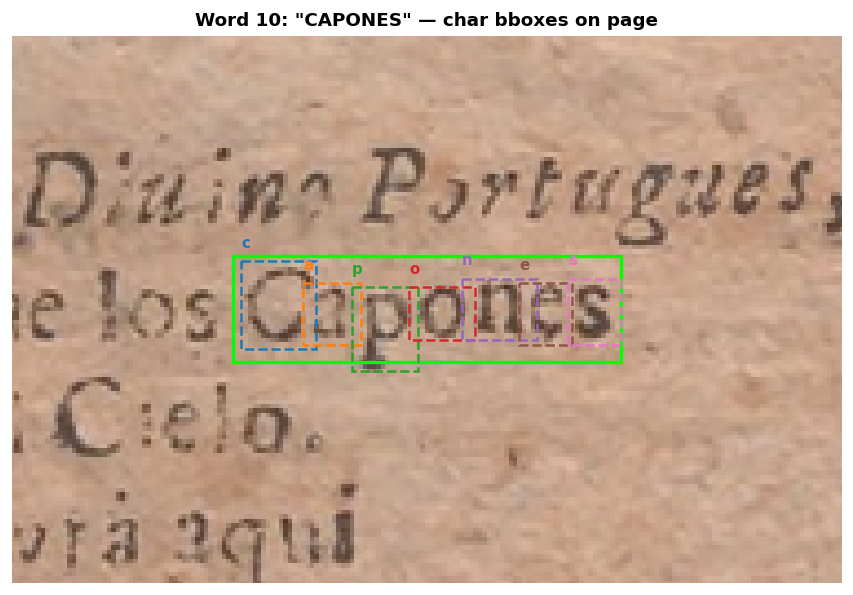

In [5]:
# Visualise the word region on the page with char boxes
fig, ax = plt.subplots(figsize=(14, 5))
pad_vis = max(50, (wb - wt))
ax.imshow(img_rgb)
ax.set_xlim(wl - pad_vis, wr + pad_vis)
ax.set_ylim(wb + pad_vis, wt - pad_vis)

# Word bbox
from matplotlib.patches import Rectangle
ax.add_patch(Rectangle((wl, wt), wr - wl, wb - wt,
             linewidth=2, edgecolor="lime", facecolor="none", label="word"))

# Char bboxes
for ci, c in enumerate(chars):
    ct, cb, cl, cr = c["tblr"]
    colour = PALETTE[ci % len(PALETTE)]
    ax.add_patch(Rectangle((cl, ct), cr - cl, cb - ct,
                 linewidth=1.5, edgecolor=colour, facecolor="none", linestyle="--"))
    top1 = max(c["labels"], key=c["labels"].get)
    ax.text(cl, ct - 3, top1, fontsize=9, color=colour, fontweight="bold")

ax.set_title(f"Word {wi}: \"{text}\" — char bboxes on page", fontweight="bold")
ax.set_axis_off()
fig.tight_layout()
plt.show()

---
## Step 3 — Crop word region (padding = height/5, expanded for char bboxes)

Crop region: t=86, b=118, l=356, r=452
Crop shape : (32, 96)
Padding    : 4 px (height/5 = 24/5)


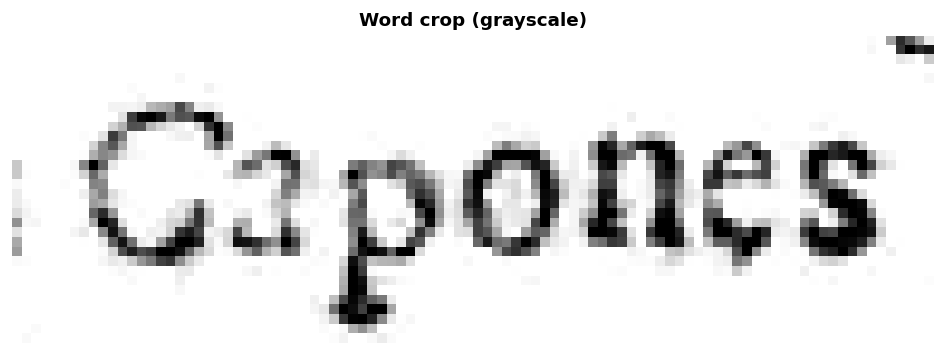

In [6]:
word_h = wb - wt
pad = max(1, word_h // 5)

# Start from word bbox + padding
crop_t, crop_b = wt - pad, wb + pad
crop_l, crop_r = wl - pad, wr + pad

# Expand to contain all char bboxes
for ct, cb, cl, cr in char_tblrs_page:
    crop_t = min(crop_t, ct)
    crop_b = max(crop_b, cb)
    crop_l = min(crop_l, cl)
    crop_r = max(crop_r, cr)

# Clamp to image bounds
crop_t = max(0, crop_t)
crop_b = min(img_gray.shape[0], crop_b)
crop_l = max(0, crop_l)
crop_r = min(img_gray.shape[1], crop_r)

word_crop = img_gray[crop_t:crop_b, crop_l:crop_r]

print(f"Crop region: t={crop_t}, b={crop_b}, l={crop_l}, r={crop_r}")
print(f"Crop shape : {word_crop.shape}")
print(f"Padding    : {pad} px (height/5 = {word_h}/5)")

fig, ax = plt.subplots(figsize=(12, 3))
ax.imshow(word_crop, cmap="gray")
ax.set_title(f"Word crop (grayscale)", fontweight="bold")
ax.set_axis_off()
fig.tight_layout()
plt.show()

---
## Step 4 — Convert char tblrs to crop-local coordinates

Local tblrs (7 valid out of 7):
  char 0: t=5, b=25, l=6, r=23  (20×17)
  char 1: t=10, b=24, l=20, r=33  (14×13)
  char 2: t=11, b=30, l=31, r=46  (19×15)
  char 3: t=11, b=23, l=44, r=59  (12×15)
  char 4: t=9, b=23, l=56, r=73  (14×17)
  char 5: t=10, b=24, l=69, r=81  (14×12)
  char 6: t=9, b=24, l=80, r=92  (15×12)


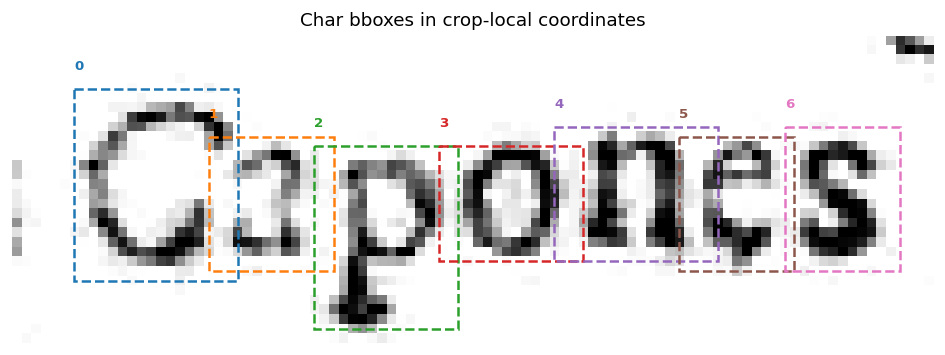

In [7]:
local_tblrs = char_tblrs_page.copy()
local_tblrs[:, 0] -= crop_t  # t
local_tblrs[:, 1] -= crop_t  # b
local_tblrs[:, 2] -= crop_l  # l
local_tblrs[:, 3] -= crop_l  # r

# Clamp to crop bounds
ch, cw = word_crop.shape
local_tblrs[:, 0] = np.clip(local_tblrs[:, 0], 0, ch - 1)
local_tblrs[:, 1] = np.clip(local_tblrs[:, 1], 1, ch)
local_tblrs[:, 2] = np.clip(local_tblrs[:, 2], 0, cw - 1)
local_tblrs[:, 3] = np.clip(local_tblrs[:, 3], 1, cw)

# Filter degenerate boxes
valid = (local_tblrs[:, 1] > local_tblrs[:, 0]) & \
        (local_tblrs[:, 3] > local_tblrs[:, 2])
local_tblrs = local_tblrs[valid]

print(f"Local tblrs ({len(local_tblrs)} valid out of {len(char_tblrs_page)}):")
for ci, (t, b, l, r) in enumerate(local_tblrs):
    print(f"  char {ci}: t={t}, b={b}, l={l}, r={r}  ({b-t}×{r-l})")

# Visualise on the crop
fig, ax = plt.subplots(figsize=(12, 3))
ax.imshow(word_crop, cmap="gray")
for ci, (t, b, l, r) in enumerate(local_tblrs):
    colour = PALETTE[ci % len(PALETTE)]
    ax.add_patch(Rectangle((l, t), r - l, b - t,
                 linewidth=1.5, edgecolor=colour, facecolor="none", linestyle="--"))
    ax.text(l, t - 2, str(ci), fontsize=8, color=colour, fontweight="bold")
ax.set_title("Char bboxes in crop-local coordinates")
ax.set_axis_off()
fig.tight_layout()
plt.show()

---
## Step 5 — `find_hor_paths` (top & bottom edges)

`char_segment` adds 1 px global padding, then crops horizontally to the
line cluster (here all chars belong to 1 cluster).  We replicate this to
show the exact inputs to `find_hor_paths`.

pre_img range: [0.0000, 1.0000]
Padded image: (34, 98)
Line crop: columns [0, 98]  →  shape (34, 98)
refwidth: 14.4


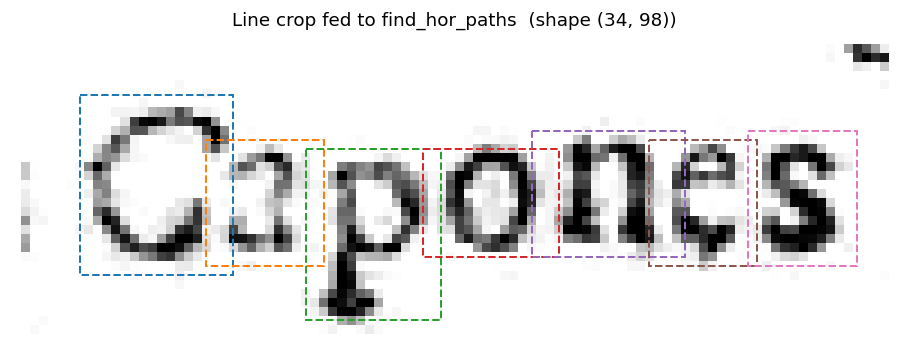

In [8]:
pre_img = word_crop.astype(np.float64)
pre_img = (pre_img - pre_img.min()) / (pre_img.max() - pre_img.min() + 1e-8)  # normalize to [0, 1]
print(f"pre_img range: [{pre_img.min():.4f}, {pre_img.max():.4f}]")

# Replicate char_segment's global padding
img_padded = np.pad(pre_img, pad_width=1, mode='constant', constant_values=1)
tblrs_padded = local_tblrs.copy() + 1  # shift for padding

h_p, w_p = img_padded.shape

# char_segment crops horizontally per line cluster
widths = local_tblrs[:, 3] - local_tblrs[:, 2]
refwidth = float(np.mean(widths)) if len(widths) > 0 else 1.0

l0 = max(0, tblrs_padded[tblrs_padded[:, 2].argmin(), 2] - int(refwidth))
r0 = min(w_p, tblrs_padded[tblrs_padded[:, 3].argmax(), 3] + int(refwidth) + 1)
line_crop = img_padded[:, l0:r0]
boxes_line = tblrs_padded.copy()
boxes_line[:, 2:] -= l0

print(f"Padded image: {img_padded.shape}")
print(f"Line crop: columns [{l0}, {r0}]  →  shape {line_crop.shape}")
print(f"refwidth: {refwidth:.1f}")

fig, ax = plt.subplots(figsize=(14, 3))
ax.imshow(line_crop, cmap="gray")
for ci, (t, b, l, r) in enumerate(boxes_line):
    colour = PALETTE[ci % len(PALETTE)]
    ax.add_patch(Rectangle((l, t), r - l, b - t,
                 linewidth=1.2, edgecolor=colour, facecolor="none", linestyle="--"))
ax.set_title(f"Line crop fed to find_hor_paths  (shape {line_crop.shape})")
ax.set_axis_off()
fig.tight_layout()
plt.show()

Top path: (114, 2)  (y range: 5-12)
Bot path: (121, 2)  (y range: 24-32)


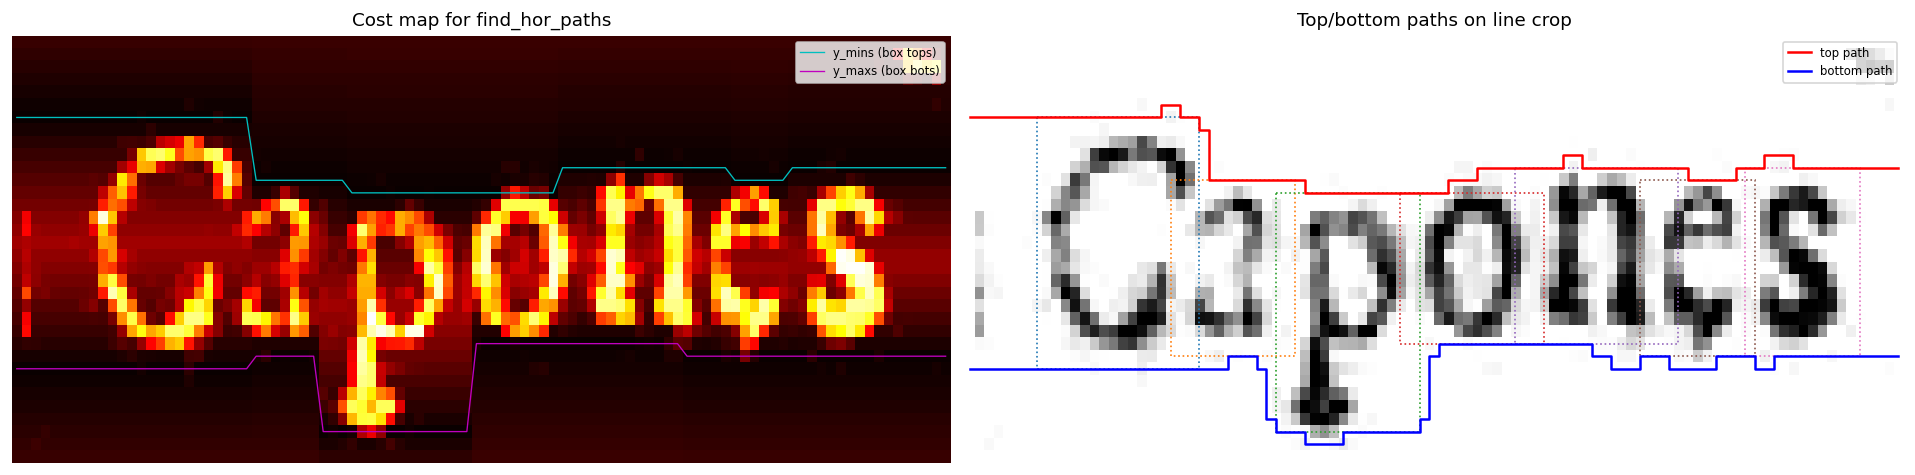

In [9]:
# Run find_hor_paths
tpath, bpath = find_hor_paths(line_crop, boxes_line, pen=0.1)

print(f"Top path: {tpath.shape}  (y range: {tpath[:,0].min()}-{tpath[:,0].max()})")
print(f"Bot path: {bpath.shape}  (y range: {bpath[:,0].min()}-{bpath[:,0].max()})")

# Visualise cost map and paths
h_lc, w_lc = line_crop.shape
yy, _ = np.indices((h_lc, w_lc))

# Reconstruct the cost map (same as find_hor_paths internals)
y_mins_plot = np.zeros(w_lc + 2, dtype=int) + h_lc - 1
y_maxs_plot = np.zeros(w_lc + 2, dtype=int)
box_cov = np.zeros(w_lc + 2, dtype=int)
for t_, b_, l_, r_ in boxes_line:
    y_mins_plot[l_+1:r_+2] = np.minimum(y_mins_plot[l_+1:r_+2], t_)
    y_maxs_plot[l_+1:r_+2] = np.maximum(y_maxs_plot[l_+1:r_+2], b_)
    box_cov[l_+1:r_+2] = 1
io_ = box_cov[1:] - box_cov[:-1]
ins_ = np.nonzero(io_ == 1)[0] + 1
outs_ = np.nonzero(io_ == -1)[0] + 1
if len(ins_) > 0 and len(outs_) > 0:
    for o, i in zip(outs_[:-1], ins_[1:]):
        y_mins_plot[o:i] = (y_mins_plot[o-1]+y_mins_plot[i])/2
        y_maxs_plot[o:i] = (y_maxs_plot[o-1]+y_maxs_plot[i])/2
    y_mins_plot[:ins_[0]] = y_mins_plot[ins_[0]]
    y_maxs_plot[:ins_[0]] = y_maxs_plot[ins_[0]]
    y_mins_plot[outs_[-1]:] = y_mins_plot[outs_[-1]-1]
    y_maxs_plot[outs_[-1]:] = y_maxs_plot[outs_[-1]-1]
y_mins_plot = y_mins_plot[1:-1]
y_maxs_plot = y_maxs_plot[1:-1]

pen = 0.1
denom_b = np.maximum(h_lc - y_maxs_plot, 1)
denom_t = np.maximum(y_mins_plot + 1, 1)
denom_m = np.maximum(y_maxs_plot - y_mins_plot + 1, 1)
costs = 1 - line_crop
costs = costs + pen * np.maximum((yy - y_maxs_plot) / denom_b,
                                  np.maximum((y_mins_plot - yy) / denom_t, 0))
costs = costs + 3 * pen * (np.maximum(0, np.minimum(yy - y_mins_plot, y_maxs_plot - yy)) / denom_m * 2)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Cost map
axes[0].imshow(costs, cmap="hot", aspect="auto")
axes[0].plot(y_mins_plot, 'c-', linewidth=0.8, label="y_mins (box tops)")
axes[0].plot(y_maxs_plot, 'm-', linewidth=0.8, label="y_maxs (box bots)")
axes[0].legend(fontsize=7)
axes[0].set_title("Cost map for find_hor_paths")

# Paths on image
axes[1].imshow(line_crop, cmap="gray", aspect="auto")
axes[1].plot(tpath[:, 1], tpath[:, 0], 'r-', linewidth=1.5, label="top path")
axes[1].plot(bpath[:, 1], bpath[:, 0], 'b-', linewidth=1.5, label="bottom path")
for ci, (t_, b_, l_, r_) in enumerate(boxes_line):
    colour = PALETTE[ci % len(PALETTE)]
    axes[1].add_patch(Rectangle((l_, t_), r_ - l_, b_ - t_,
                      linewidth=1, edgecolor=colour, facecolor="none", linestyle=":"))
axes[1].legend(fontsize=7)
axes[1].set_title("Top/bottom paths on line crop")

for a in axes: a.set_axis_off()
fig.tight_layout()
plt.show()

---
## Step 6 — `find_vert_paths` (left & right character boundaries)

Vertical min-cost paths are found iteratively, increasing the background cost
until width conditions are met or `bgcost_max` is reached.

In [10]:
# Run find_vert_paths
lrs = boxes_line[:, 2:]  # (n, 2) = (left, right) in line-crop coords
paths_list = find_vert_paths((1 - line_crop), lrs, tpath, bpath)

print(f"Found {len(paths_list)} character path pairs")
for ci, (lp, rp) in enumerate(paths_list):
    print(f"  char {ci}: lpath {lp.shape}, rpath {rp.shape}  "
          f"x_range=[{lp[:,1].min()}-{rp[:,1].max()}]")

Found 7 character path pairs
  char 0: lpath (21, 2), rpath (21, 2)  x_range=[5-24]
  char 1: lpath (21, 2), rpath (21, 2)  x_range=[23-34]
  char 2: lpath (20, 2), rpath (19, 2)  x_range=[32-47]
  char 3: lpath (20, 2), rpath (15, 2)  x_range=[45-58]
  char 4: lpath (15, 2), rpath (16, 2)  x_range=[59-72]
  char 5: lpath (16, 2), rpath (16, 2)  x_range=[72-82]
  char 6: lpath (16, 2), rpath (16, 2)  x_range=[81-93]


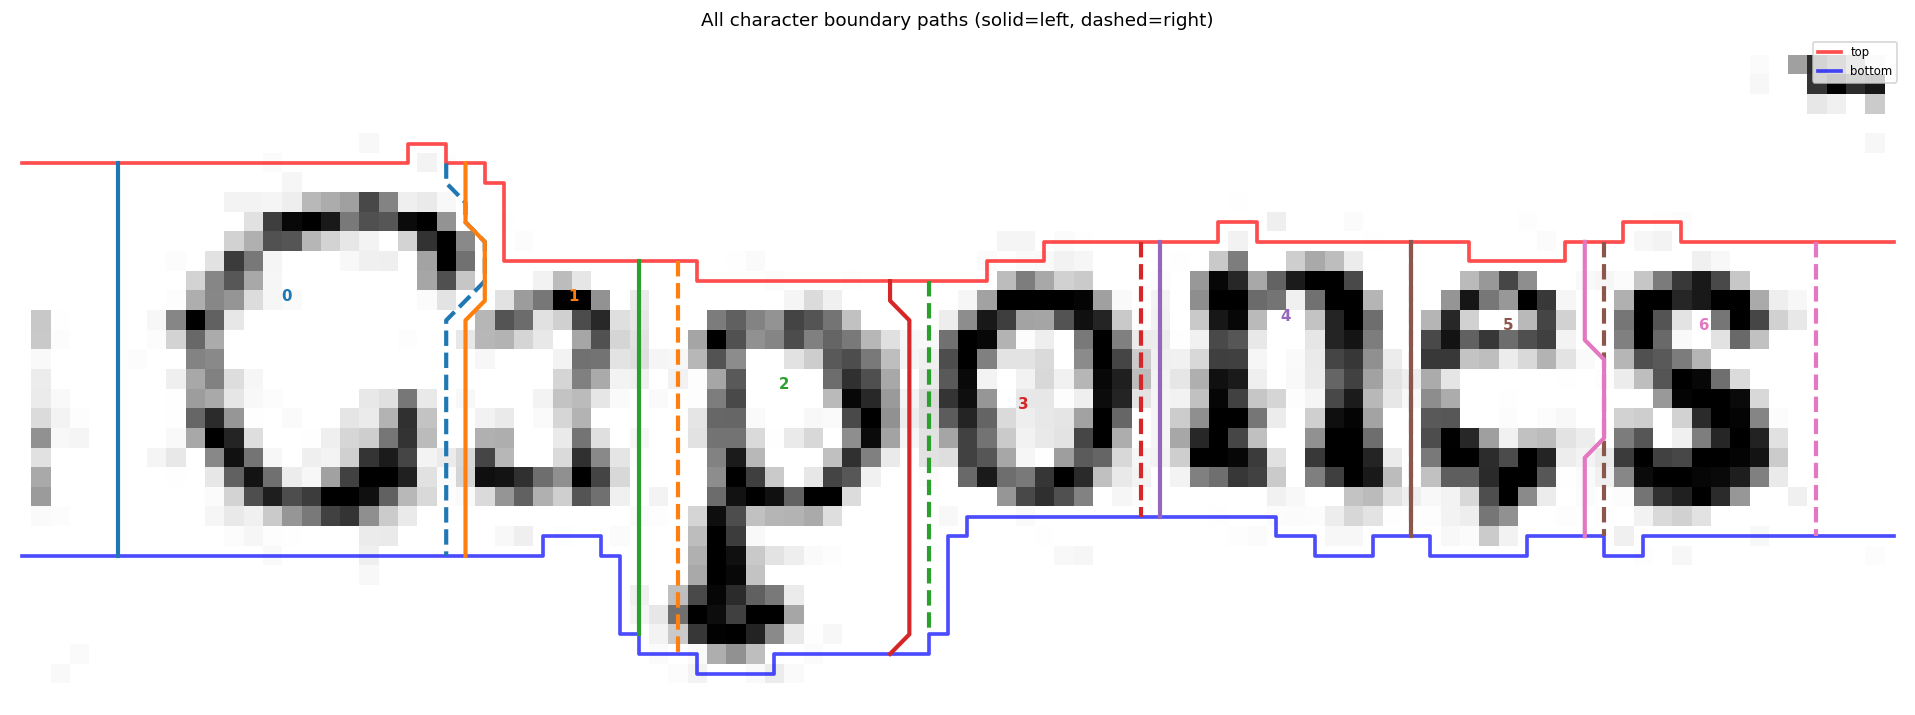

In [11]:
# Visualise all vertical paths overlaid on the line crop
fig, ax = plt.subplots(figsize=(16, 6))
ax.imshow(line_crop, cmap="gray", aspect="auto")

# Top/bottom paths
ax.plot(tpath[:, 1], tpath[:, 0], 'r-', linewidth=2.2, alpha=0.7, label="top")
ax.plot(bpath[:, 1], bpath[:, 0], 'b-', linewidth=2.2, alpha=0.7, label="bottom")

# Vertical paths
for ci, (lpath_v, rpath_v) in enumerate(paths_list):
    colour = PALETTE[ci % len(PALETTE)]
    ax.plot(lpath_v[:, 1], lpath_v[:, 0], '-', color=colour, linewidth=2.5)
    ax.plot(rpath_v[:, 1], rpath_v[:, 0], '--', color=colour, linewidth=2.5)
    # Label
    mid_y = lpath_v[:, 0].mean()
    mid_x = (lpath_v[:, 1].mean() + rpath_v[:, 1].mean()) / 2
    ax.text(mid_x, mid_y - 3, str(ci), fontsize=9, color=colour,
            fontweight="bold", ha="center")

ax.legend(fontsize=7)
ax.set_title("All character boundary paths (solid=left, dashed=right)")
ax.set_axis_off()
fig.tight_layout()
plt.show()

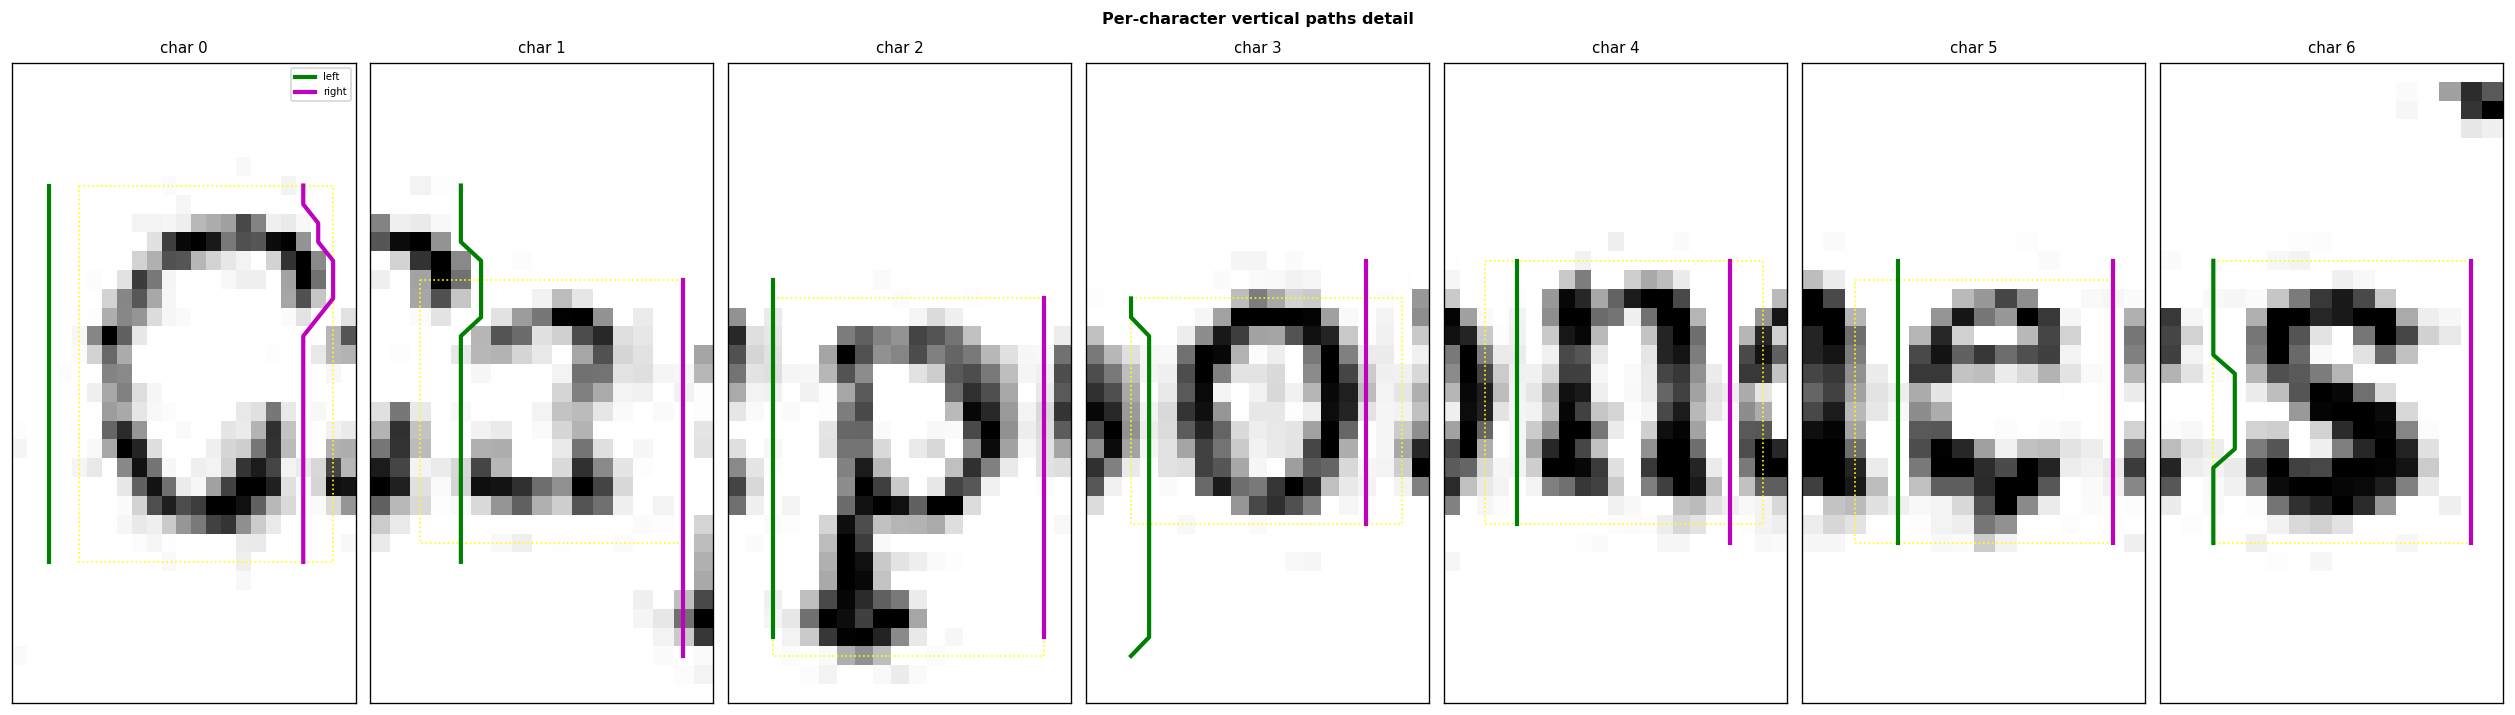

In [12]:
# Individual character path detail
n_show = min(len(paths_list), 8)
fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 6))
if n_show == 1:
    axes = [axes]

for ci in range(n_show):
    lpath_v, rpath_v = paths_list[ci]
    t_, b_, l_, r_ = boxes_line[ci]

    # Determine horizontal extent for this character
    x_lo = max(0, min(lpath_v[:, 1].min(), l_) - 2)
    x_hi = min(line_crop.shape[1], max(rpath_v[:, 1].max(), r_) + 2)

    ax = axes[ci]
    ax.imshow(line_crop[:, x_lo:x_hi], cmap="gray", aspect="auto")
    ax.plot(lpath_v[:, 1] - x_lo, lpath_v[:, 0], 'g-', linewidth=2.5, label="left")
    ax.plot(rpath_v[:, 1] - x_lo, rpath_v[:, 0], 'm-', linewidth=2.5, label="right")
    ax.add_patch(Rectangle((l_ - x_lo, t_), r_ - l_, b_ - t_,
                 linewidth=1, edgecolor="yellow", facecolor="none", linestyle=":"))
    ax.set_title(f"char {ci}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    if ci == 0:
        ax.legend(fontsize=6)

fig.suptitle("Per-character vertical paths detail", fontweight="bold")
fig.tight_layout()
plt.show()

---
## Step 7 — Mask extraction (connected component + white removal)

For each character, the four boundary paths (top, bottom, left, right) form
a closed region. The mask is the complement of the edge-connected component
(background), with white pixels removed.

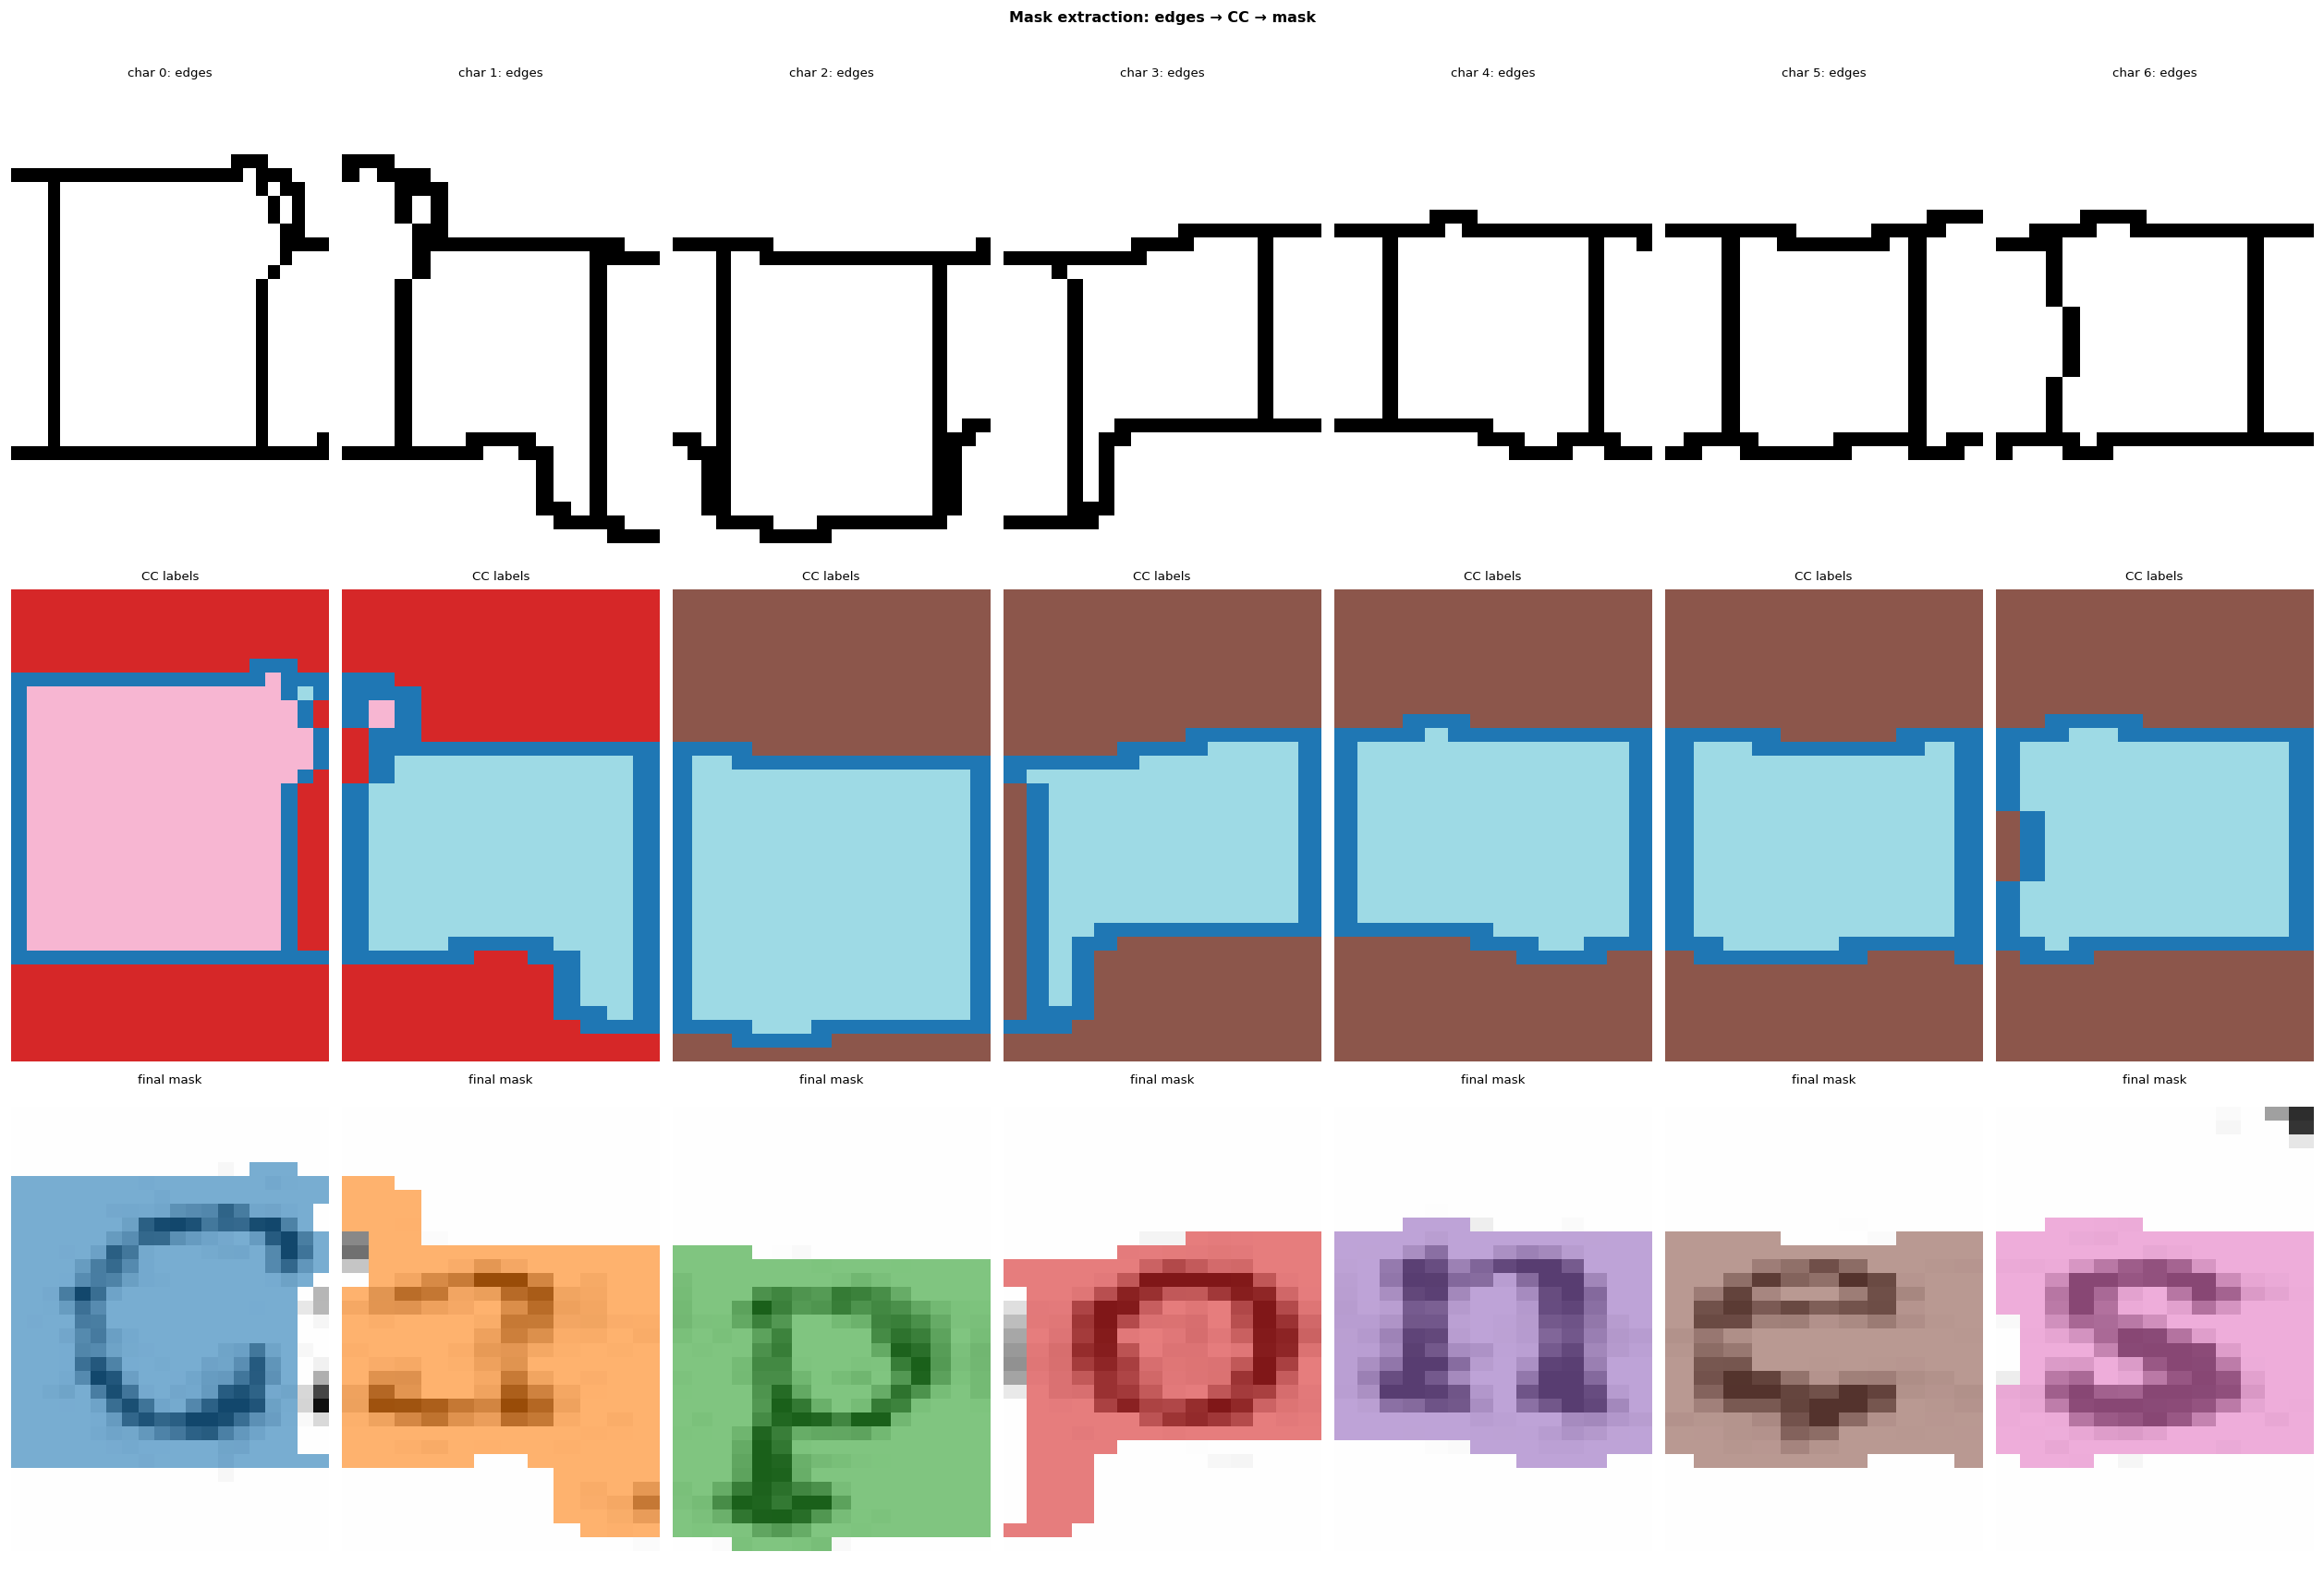

In [13]:
# Replicate the mask extraction loop from char_segment
canv = np.zeros(line_crop.shape, dtype=bool)
canv[*(tpath.T)] = True
canv[*(bpath.T)] = True

n_show = min(len(paths_list), 8)
fig, axes = plt.subplots(3, n_show, figsize=(3 * n_show, 14))
if n_show == 1:
    axes = axes.reshape(3, 1)

for ci, (lpath_v, rpath_v) in enumerate(paths_list[:n_show]):
    # Build the closed boundary canvas
    canv_char = canv.copy()
    canv_char[*(lpath_v.T)] = True
    canv_char[*(rpath_v.T)] = True
    l_v = lpath_v[:, 1].min()
    r_v = rpath_v[:, 1].max()
    canv_char_crop = np.pad(canv_char[:, l_v:r_v+1], pad_width=1)

    # Connected components
    char_comps = ski.measure.label(~canv_char_crop, connectivity=1)
    premask = (char_comps != char_comps[0, 0])[1:-1, 1:-1]

    # Remove white pixels
    premask_clean = premask & (line_crop[:, l_v:r_v+1] != 1)

    # Row 0: boundary canvas
    axes[0, ci].imshow(canv_char[:, max(0,l_v-3):r_v+4], cmap="gray_r", aspect="auto")
    axes[0, ci].set_title(f"char {ci}: edges", fontsize=8)
    axes[0, ci].set_axis_off()

    # Row 1: connected component labels
    axes[1, ci].imshow(char_comps[1:-1, 1:-1], cmap="tab20", aspect="auto")
    axes[1, ci].set_title("CC labels", fontsize=8)
    axes[1, ci].set_axis_off()

    # Row 2: final mask overlaid on image
    char_crop_img = line_crop[:, l_v:r_v+1]
    overlay = np.stack([char_crop_img]*3, axis=-1).astype(np.float64) / 255.0 if char_crop_img.max() > 1 else np.stack([char_crop_img]*3, axis=-1)
    if premask_clean.any():
        colour = np.array(mcolors.to_rgb(PALETTE[ci % len(PALETTE)]))
        overlay[premask_clean] = overlay[premask_clean] * 0.4 + colour * 0.6
    axes[2, ci].imshow(overlay, aspect="auto")
    axes[2, ci].set_title("final mask", fontsize=8)
    axes[2, ci].set_axis_off()

fig.suptitle("Mask extraction: edges → CC → mask", fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

---
## Step 8 — Run `char_segment` end-to-end and compare

Run the full `char_segment` function and visualise the output masks
overlaid on the word crop.

In [14]:
box_clu = np.ones(len(local_tblrs), dtype=int)
char_data, idxs_input = char_segment(pre_img, local_tblrs.copy(), box_clu, refwidth)

print(f"char_segment returned {len(char_data)} characters "
      f"(from {len(local_tblrs)} input boxes)")
for ci, ((t, b, l, r), mask) in enumerate(char_data):
    print(f"  char {ci}: tblr=[{t},{b},{l},{r}]  mask {mask.shape}  "
          f"px={mask.sum()}")

char_segment returned 7 characters (from 7 input boxes)
  char 0: tblr=[4,26,4,24]  mask (22, 20)  px=396
  char 1: tblr=[5,31,22,34]  mask (26, 12)  px=219
  char 2: tblr=[10,32,31,47]  mask (22, 16)  px=329
  char 3: tblr=[9,31,44,58]  mask (22, 14)  px=208
  char 4: tblr=[8,26,58,72]  mask (18, 14)  px=225
  char 5: tblr=[9,26,71,82]  mask (17, 11)  px=179
  char 6: tblr=[8,26,80,93]  mask (18, 13)  px=210


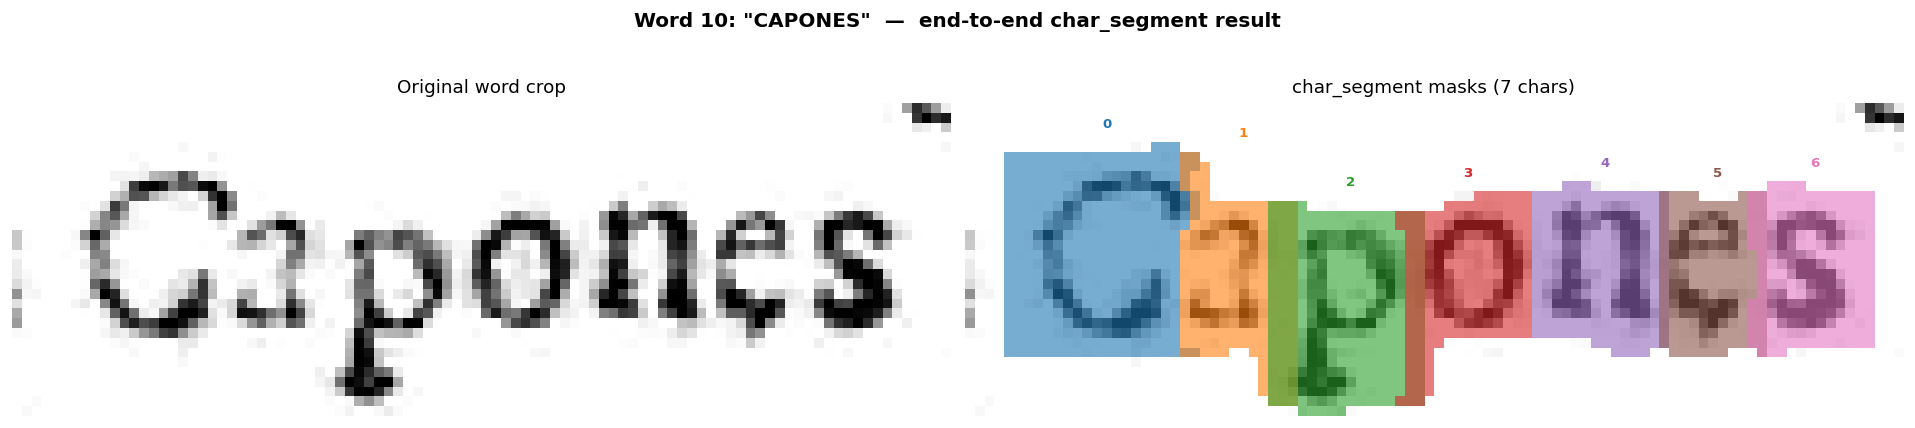

In [15]:
# Overlay all masks on the word crop (pre-padded image coords need
# to be shifted back by -1 to remove global padding)
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Left: original crop
axes[0].imshow(word_crop, cmap="gray")
axes[0].set_title("Original word crop")
axes[0].set_axis_off()

# Right: masks overlaid
word_overlay = np.stack([word_crop]*3, axis=-1).astype(np.float64)
if word_overlay.max() > 1:
    word_overlay /= 255.0

for ci, ((t, b, l, r), mask) in enumerate(char_data):
    # char_segment tblrs include the global +1 padding; undo it
    pt, pb, pl, pr = t , b , l , r 
    colour = np.array(mcolors.to_rgb(PALETTE[ci % len(PALETTE)]))

    # Clamp to crop
    ch, cw = word_crop.shape
    ot = max(pt, 0); ob = min(pb, ch)
    ol = max(pl, 0); or_ = min(pr, cw)
    mt = ot - pt; mb = mask.shape[0] - (pb - ob)
    ml = ol - pl; mr = mask.shape[1] - (pr - or_)
    if ot >= ob or ol >= or_:
        continue
    m_slice = mask[mt:mb, ml:mr]

    roi = word_overlay[ot:ob, ol:or_]
    roi[m_slice] = roi[m_slice] * 0.4 + colour * 0.6

    # Label
    axes[1].text((ol + or_) / 2, ot - 2, str(ci), fontsize=8,
                 color=PALETTE[ci % len(PALETTE)], fontweight="bold",
                 ha="center")

axes[1].imshow(np.clip(word_overlay, 0, 1))
axes[1].set_title(f"char_segment masks ({len(char_data)} chars)")
axes[1].set_axis_off()

fig.suptitle(f"Word {wi}: \"{text}\"  —  end-to-end char_segment result",
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

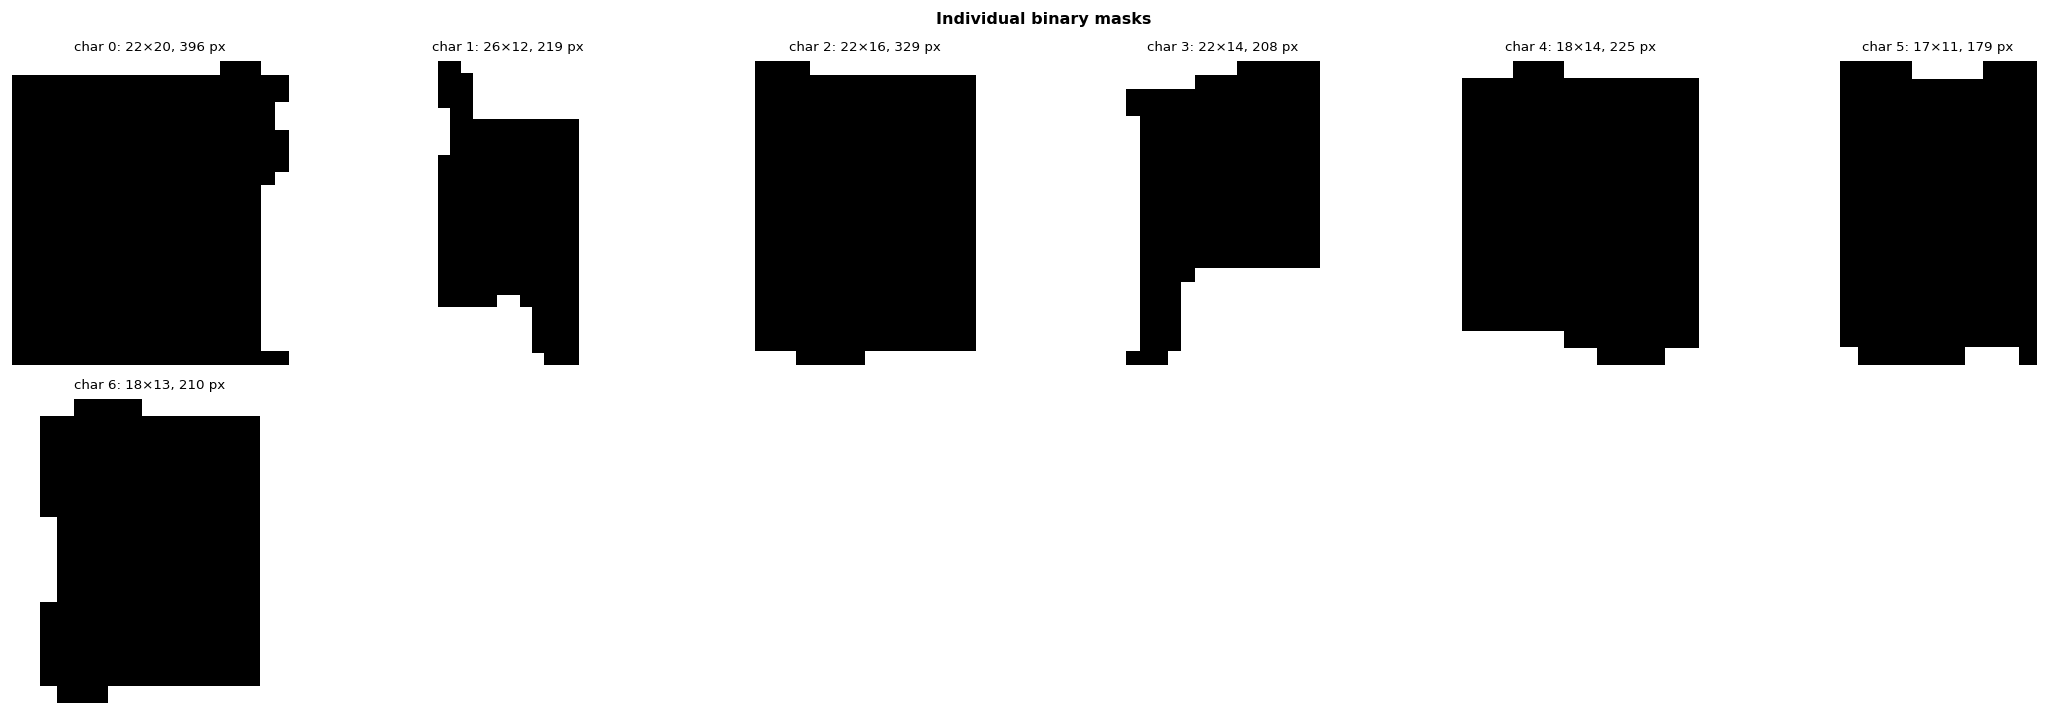

In [16]:
# Individual masks at full resolution
n_show = min(len(char_data), 12)
cols = min(n_show, 6)
rows = (n_show + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
axes = np.atleast_2d(axes)

for ci in range(n_show):
    (t, b, l, r), mask = char_data[ci]
    ax = axes[ci // cols, ci % cols]
    # Show mask
    ax.imshow(mask, cmap="gray_r", aspect="equal", interpolation="nearest")
    ax.set_title(f"char {ci}: {mask.shape[0]}×{mask.shape[1]}, {mask.sum()} px",
                 fontsize=8)
    ax.set_axis_off()

# Hide unused axes
for ci in range(n_show, rows * cols):
    axes[ci // cols, ci % cols].set_visible(False)

fig.suptitle("Individual binary masks", fontweight="bold")
fig.tight_layout()
plt.show()